This file contains:
- Fig. 15
- Fig. 16

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import helper

from pathlib import Path

Loading library list...
Done


## Save Plots

In [2]:
# Save plots
save_plt = False

## Import Options Data, Risk-Free Data, and CRSP Data

In [3]:
# Define ticker symbols to be analyzed
tickers_array = ['APA', 'COP', 'CVX', 'DVN', 'EOG', 'HAL', 'MRO', 'OXY', 'VLO', 'XOM']

# Define time range
start_year = 2005
end_year   = 2022

# Upload Fama-French daily risk-free rate
ff_daily = helper.rf_data(start_year, end_year)

# Upload CRSP data as a dictionary
ret_tickers = helper.crsp_data(tickers_array, start_year, end_year)
# Get one single dataframe from the dictionary
df_tickers  = pd.concat(ret_tickers, ignore_index=True)

# Get dividends data
ret_div = helper.crsp_dividends(tickers_array, start_year, end_year)

# Set list to store options data
all_options = []

# Run loop to get options data
for year in range(start_year, end_year + 1):
    print(f'Processing data for {year}')
    options = helper.options_data(year, min_option_vol=1)
    options = options[options['ticker'].isin(tickers_array)]
    all_options.append(options)

# Set options dataframe
options_df = pd.concat(all_options, ignore_index=True)

Processing data for 2005
Processing data for 2006
Processing data for 2007
Processing data for 2008
Processing data for 2009
Processing data for 2010
Processing data for 2011
Processing data for 2012
Processing data for 2013
Processing data for 2014
Processing data for 2015
Processing data for 2016
Processing data for 2017
Processing data for 2018
Processing data for 2019
Processing data for 2020
Processing data for 2021
Processing data for 2022


## Filter Data

In [4]:
# Set list to store filtered dataframe
opt = []

# Run loop to filter for time-to-maturity, minimum # of strikes, and arbitrage-free options
for t in tickers_array:
    df = helper.filter_data(options_df, t, min_maturity=7, max_maturity=365, min_strikes=5)
    df = pd.merge(df, ff_daily[["date", "rf"]], on="date") # Merge filtered dataframe with risk-free rate
    opt.append(df)

# Set dataframe
opt_df = pd.concat(opt, ignore_index=True)

# Filter out options where bid > ask
opt_df = opt_df[opt_df['best_bid'] <= opt_df['best_offer']].copy()

# Filter for only standard option contracts
opt_df = opt_df[opt_df['ss_flag'] == '0'].copy()

# Filter for open_interest > 0
opt_df = opt_df[opt_df['open_interest'] > 0].copy()

# Filter for minimum prices
opt_df = opt_df[opt_df['opt_price'] >= 0.375].copy()

# Filter by moneyness
opt_df = opt_df[(opt_df['moneyness'] >= 0.8) & (opt_df['moneyness'] <= 1.2)].copy()

# Keep only desired variables
opt_df = opt_df[['date', 'ticker', 'cp_flag', 'optionid', 'strike_price', 'opt_price', 
                 'maturity_days', 'spot_price', 'moneyness', 'log_moneyness', 'rf']].copy()

# Create year column
opt_df['year'] = opt_df['date'].dt.year

# Create %moneyness column
opt_df['%moneyness'] = opt_df['moneyness'] - 1

# Organize dataframe for calls and puts
calls_df = opt_df[opt_df['cp_flag'] == 'C'].copy()
puts_df  = opt_df[opt_df['cp_flag'] == 'P'].copy()

# Get constant dividend yield
div_yield = helper.const_div_yield(ret_div, df_tickers)

# Merge constant dividend yield to options dataframe
calls_df = pd.merge(calls_df, div_yield[['ticker', 'year', 'q']], on=['ticker', 'year'])

## Filter Data (90 days)

In [5]:
# Set list to store filtered dataframe
opt_mat = []

# Run loop to filter for time-to-maturity, minimum # of strikes, and arbitrage-free options
for t in tickers_array:
    df = helper.filter_data(options_df, t, min_maturity=7, max_maturity=90, min_strikes=5)
    df = pd.merge(df, ff_daily[["date", "rf"]], on="date") # Merge filtered dataframe with risk-free rate
    opt_mat.append(df)

# Set dataframe
opt_df_mat = pd.concat(opt_mat, ignore_index=True)

# Filter out options where bid > ask
opt_df_mat = opt_df_mat[opt_df_mat['best_bid'] <= opt_df_mat['best_offer']].copy()

# Filter for only standard option contracts
opt_df_mat = opt_df_mat[opt_df_mat['ss_flag'] == '0'].copy()

# Filter for open_interest > 0
opt_df_mat = opt_df_mat[opt_df_mat['open_interest'] > 0].copy()

# Filter for minimum prices
opt_df_mat = opt_df_mat[opt_df_mat['opt_price'] >= 0.375].copy()

# Filter by moneyness
opt_df_mat = opt_df_mat[(opt_df_mat['moneyness'] >= 0.8) & (opt_df_mat['moneyness'] <= 1.2)].copy()

# Keep only desired variables
opt_df_mat = opt_df_mat[['date', 'ticker', 'cp_flag', 'optionid', 'strike_price', 'opt_price', 
                 'maturity_days', 'spot_price', 'moneyness', 'log_moneyness', 'rf']].copy()

# Create year column
opt_df_mat['year'] = opt_df_mat['date'].dt.year

# Create %moneyness column
opt_df_mat['%moneyness'] = opt_df_mat['moneyness'] - 1

# Organize dataframe for calls and puts
calls_df_mat = opt_df_mat[opt_df_mat['cp_flag'] == 'C'].copy()
puts_df_mat  = opt_df_mat[opt_df_mat['cp_flag'] == 'P'].copy()

# Get constant dividend yield
div_yield = helper.const_div_yield(ret_div, df_tickers)

# Merge constant dividend yield to options dataframe
calls_df_mat = pd.merge(calls_df_mat, div_yield[['ticker', 'year', 'q']], on=['ticker', 'year'])

## Estimate Jump-Diffusion Modeled Prices

In [6]:
# Set rolling window
rolling_window = 3

# Set indexed dataframe
calls_idx = calls_df.set_index(['ticker', 'year']).sort_index()

# Get starting values
sv = helper.starting_values(df_tickers, tickers_array, rolling_window=rolling_window)
sv_idx = sv.set_index(['ticker', 'start_year', 'end_year']).sort_index()

# Define bounds (constant)
lb, ub = helper.default_bounds(['sigma', 'lam', 'mu', 'delta'])

# Set lists to store results
param_list_merton, stats_list_merton = [], []
prices_m = {}

# Run loop for estimating prices per ticker
for t in tickers_array:
    # Set years list from the dataframe
    years = calls_idx.loc[t].index.unique().to_list()

    # Run loop for rolling window
    for i in range (0, len(years), rolling_window):
        # Set start of rolling window
        start = years[i]
        # Set end of rolling window
        end   = start + rolling_window - 1
        
        # Set options within the rollinw window
        try:
            window_df = calls_idx.loc[(t, slice(start, end)), :].reset_index()
        except KeyError:
            continue
        # Set starting values within the rolling window
        try:
            sv_row = sv_idx.loc[(t, start, end)]
        except KeyError:
            continue

        # Set parameters starting values
        sigma0 = sv_row['imp_vol']
        lam0   = sv_row['jump_arrival']
        mu0    = sv_row['jump_mean']
        delta0 = sv_row['jump_vol']

        x0 = [sigma0, lam0, mu0, delta0]

        # Prepare market inputs
        S, K, tau, r, q, C_mkt = helper.prepare_inputs(window_df)

        # Estimate parameters
        theta, res, free_keys = helper.calibrate_merton(
            S=S, K=K, tau=tau, r=r, q=q, C_mkt=C_mkt,
            x0=x0,
            bounds=(lb, ub),
            n_max=10,
            method='trf',
            tol=1e-10,
            max_nfev=1500,
            verbose=0
        )
        # Store parameters by ticker and rolling window
        param = {
                'ticker'    : t,
                'start_year': start,
                'end_year'  : end,
                'sigma'     : theta['sigma'],
                'lam'       : theta['lam'],
                'mu'        : theta['mu'],
                'delta'     : theta['delta']
            }

        # Estimate jump-diffusion prices
        m_price = helper.merton_call_vec(S, K, tau, r, q, theta['sigma'], theta['lam'], 
                                               theta['mu'], theta['delta'], n_max=10)
        # Store modeled prices in the dataframe
        window_df['C_model'] = m_price
        # Get error column
        window_df['error']   = window_df["opt_price"] - window_df["C_model"]
        # Get %error column in percetage points
        window_df['%error']  = (window_df["error"] / window_df["opt_price"]) * 100

        # Get RMSE
        rmse = np.sqrt(np.mean(window_df['error']**2))
        # Get normalized RMSE by mean
        nrmse_mean = rmse / np.mean(C_mkt)
        # Get normalized RMSE by std
        nrmse_std  = rmse / np.std(C_mkt, ddof=1)
        # Store RMSE stats by ticker and rolling window
        stats = {
            'ticker'     : t,
            'start_year' : start,
            'end_year'   : end,
            'n_obs'      : len(window_df),
            'rmse'       : rmse,
            'nrmse_mean' : nrmse_mean,
            'nrmse_std' :  nrmse_std
        }

        # Store estimated parameters
        param_list_merton.append(param)
        # Store stats
        stats_list_merton.append(stats)
        # Store modeled prices
        prices_m[(t, start, end)] = window_df

# Get estimated parameters dataframe
param_m_df = pd.DataFrame(param_list_merton)
# Get stats dataframe
stats_m_df = pd.DataFrame(stats_list_merton)
# Get modeled prices dataframe
price_m_df = (
    pd.concat({k: df.drop(columns=["ticker"]) for k, df in prices_m.items()},
              names=["ticker", "start_year", "end_year"])
      .reset_index(level=[0, 1, 2])
      .reset_index(drop=True)
)

## Estimate Jump-Diffusion Modeled Prices (90 days)

In [7]:
# Set rolling window
rolling_window = 3

# Set indexed dataframe
calls_idx_mat = calls_df_mat.set_index(['ticker', 'year']).sort_index()

# Get starting values
sv = helper.starting_values(df_tickers, tickers_array, rolling_window=rolling_window)
sv_idx = sv.set_index(['ticker', 'start_year', 'end_year']).sort_index()

# Define bounds (constant)
lb, ub = helper.default_bounds(['sigma', 'lam', 'mu', 'delta'])

# Set lists to store results
param_list_merton_mat, stats_list_merton_mat = [], []
prices_m_mat = {}

# Run loop for estimating prices per ticker
for t in tickers_array:
    # Set years list from the dataframe
    years = calls_idx_mat.loc[t].index.unique().to_list()

    # Run loop for rolling window
    for i in range (0, len(years), rolling_window):
        # Set start of rolling window
        start = years[i]
        # Set end of rolling window
        end   = start + rolling_window - 1
        
        # Set options within the rollinw window
        try:
            window_df = calls_idx_mat.loc[(t, slice(start, end)), :].reset_index()
        except KeyError:
            continue
        # Set starting values within the rolling window
        try:
            sv_row = sv_idx.loc[(t, start, end)]
        except KeyError:
            continue

        # Set parameters starting values
        sigma0 = sv_row['imp_vol']
        lam0   = sv_row['jump_arrival']
        mu0    = sv_row['jump_mean']
        delta0 = sv_row['jump_vol']

        x0 = [sigma0, lam0, mu0, delta0]

        # Prepare market inputs
        S, K, tau, r, q, C_mkt = helper.prepare_inputs(window_df)

        # Estimate parameters
        theta, res, free_keys = helper.calibrate_merton(
            S=S, K=K, tau=tau, r=r, q=q, C_mkt=C_mkt,
            x0=x0,
            bounds=(lb, ub),
            n_max=10,
            method='trf',
            tol=1e-10,
            max_nfev=1500,
            verbose=0
        )
        # Store parameters by ticker and rolling window
        param = {
                'ticker'    : t,
                'start_year': start,
                'end_year'  : end,
                'sigma'     : theta['sigma'],
                'lam'       : theta['lam'],
                'mu'        : theta['mu'],
                'delta'     : theta['delta']
            }

        # Estimate jump-diffusion prices
        m_price = helper.merton_call_vec(S, K, tau, r, q, theta['sigma'], theta['lam'], 
                                               theta['mu'], theta['delta'], n_max=10)
        # Store modeled prices in the dataframe
        window_df['C_model'] = m_price
        # Get error column
        window_df['error']   = window_df["opt_price"] - window_df["C_model"]
        # Get %error column in percetage points
        window_df['%error']  = (window_df["error"] / window_df["opt_price"]) * 100

        # Get RMSE
        rmse = np.sqrt(np.mean(window_df['error']**2))
        # Get normalized RMSE by mean
        nrmse_mean = rmse / np.mean(C_mkt)
        # Get normalized RMSE by std
        nrmse_std  = rmse / np.std(C_mkt, ddof=1)
        # Store RMSE stats by ticker and rolling window
        stats = {
            'ticker'     : t,
            'start_year' : start,
            'end_year'   : end,
            'n_obs'      : len(window_df),
            'rmse'       : rmse,
            'nrmse_mean' : nrmse_mean,
            'nrmse_std' :  nrmse_std
        }

        # Store estimated parameters
        param_list_merton_mat.append(param)
        # Store stats
        stats_list_merton_mat.append(stats)
        # Store modeled prices
        prices_m_mat[(t, start, end)] = window_df

# Get estimated parameters dataframe
param_m_df_mat = pd.DataFrame(param_list_merton_mat)
# Get stats dataframe
stats_m_df_mat = pd.DataFrame(stats_list_merton_mat)
# Get modeled prices dataframe
price_m_df_mat = (
    pd.concat({k: df.drop(columns=["ticker"]) for k, df in prices_m_mat.items()},
              names=["ticker", "start_year", "end_year"])
      .reset_index(level=[0, 1, 2])
      .reset_index(drop=True)
)

## Estimate Black-Scholes Modeled Prices

In [8]:
# Set rolling window
rolling_window = 3

# Set indexed dataframe
calls_idx = calls_df.set_index(['ticker', 'year']).sort_index()

# Get starting values
sv = helper.starting_values(df_tickers, tickers_array, rolling_window=rolling_window)
sv_idx = sv.set_index(['ticker', 'start_year', 'end_year']).sort_index()

# Define bounds (constant)
lb, ub = helper.default_bounds(['sigma'])

# Set lists to store results
param_list_bs, stats_list_bs = [], []
price_b = {}

# Run loop for estimating prices per ticker
for t in tickers_array:
    # Set years list from the dataframe
    years = calls_idx.loc[t].index.unique().to_list()
    
    # Run loop for rolling window
    for i in range (0, len(years), rolling_window):
        # Set start of rolling window
        start = years[i]
        # Set end of rolling window
        end   = start + rolling_window - 1
        
        # Set options within the rollinw window
        try:
            window_df = calls_idx.loc[(t, slice(start, end)), :].reset_index()
        except KeyError:
            continue
        # Set starting values within the rollinw window 
        try:
            sv_row = sv_idx.loc[(t, start, end)]
        except KeyError:
            continue
        
        # Set jump parameters to zero
        fixed = {
        'lam': 0,
        'mu':   0,   
        'delta': 0    
        }
        
        # Get starting value for sigma
        sigma0 = sv_row['imp_vol']
        x0 = [sigma0]
        
        # Prepare market inputs
        S, K, tau, r, q, C_mkt = helper.prepare_inputs(window_df)
        
        # Estimate sigma
        theta, res, free_keys = helper.calibrate_merton(
            S=S, K=K, tau=tau, r=r, q=q, C_mkt=C_mkt,
            fixed=fixed,
            x0=x0,
            bounds=(lb, ub),
            n_max=10,
            method='trf',
            tol=1e-10,
            max_nfev=1500,
            verbose=0
        )
        # Store sigma by ticker and rolling window
        param = {
                'ticker'    : t,
                'start_year': start,
                'end_year'  : end,
                'sigma'     : theta['sigma'],
                'lam'       : theta['lam'],
                'mu'        : theta['mu'],
                'delta'     : theta['delta']
            }
        
        # Estimate Black-Scholes prices
        m_price = helper.merton_call_vec(S, K, tau, r, q, theta['sigma'], theta['lam'], 
                                               theta['mu'], theta['delta'], n_max=10)
        # Store modeled prices in the dataframe
        window_df['C_model'] = m_price
        # Get error column (option market price - modeled price)
        window_df['error']   = window_df["opt_price"] - window_df["C_model"]
        # Get %error column in percentage points
        window_df['%error']  = (window_df["error"] / window_df["opt_price"]) * 100
        
        # Get RMSE
        rmse = np.sqrt(np.mean(window_df['error']**2))
        # Get normalized RMSE by mean
        nrmse_mean = rmse / np.mean(C_mkt)
        # Get normalized RMSE by std
        nrmse_std  = rmse / np.std(C_mkt, ddof=1)
        # Store RMSE stats by ticker and rolling window
        stats = {
            'ticker'     : t,
            'start_year' : start,
            'end_year'   : end,
            'n_obs'      : len(window_df),
            'rmse'       : rmse,
            'nrmse_mean' : nrmse_mean,
            'nrmse_std' :  nrmse_std
        }
        
        # Store estimated parameters
        param_list_bs.append(param)
        # Store stats
        stats_list_bs.append(stats)
        # Store Black-Scholes prices
        price_b[(t, start, end)] = window_df

# Get estimated parameters dataframe
param_b_df = pd.DataFrame(param_list_bs)
# Get stats dataframe
stats_b_df = pd.DataFrame(stats_list_bs)
# Get estimated prices dataframe
price_b_df = (
    pd.concat({k: df.drop(columns=["ticker"]) for k, df in price_b.items()},
              names=["ticker", "start_year", "end_year"])
      .reset_index(level=[0, 1, 2])
      .reset_index(drop=True)
)

## Estimate Black-Scholes Modeled Prices (90 days)

In [9]:
# Set rolling window
rolling_window = 3

# Set indexed dataframe
calls_idx_mat = calls_df_mat.set_index(['ticker', 'year']).sort_index()

# Get starting values
sv = helper.starting_values(df_tickers, tickers_array, rolling_window=rolling_window)
sv_idx = sv.set_index(['ticker', 'start_year', 'end_year']).sort_index()

# Define bounds (constant)
lb, ub = helper.default_bounds(['sigma'])

# Set lists to store results
param_list_bs_mat, stats_list_bs_mat = [], []
price_b_mat = {}

# Run loop for estimating prices per ticker
for t in tickers_array:
    # Set years list from the dataframe
    years = calls_idx_mat.loc[t].index.unique().to_list()
    
    # Run loop for rolling window
    for i in range (0, len(years), rolling_window):
        # Set start of rolling window
        start = years[i]
        # Set end of rolling window
        end   = start + rolling_window - 1
        
        # Set options within the rollinw window
        try:
            window_df = calls_idx_mat.loc[(t, slice(start, end)), :].reset_index()
        except KeyError:
            continue
        # Set starting values within the rollinw window 
        try:
            sv_row = sv_idx.loc[(t, start, end)]
        except KeyError:
            continue
        
        # Set jump parameters to zero
        fixed = {
        'lam': 0,
        'mu':   0,   
        'delta': 0    
        }
        
        # Get starting value for sigma
        sigma0 = sv_row['imp_vol']
        x0 = [sigma0]
        
        # Prepare market inputs
        S, K, tau, r, q, C_mkt = helper.prepare_inputs(window_df)
        
        # Estimate sigma
        theta, res, free_keys = helper.calibrate_merton(
            S=S, K=K, tau=tau, r=r, q=q, C_mkt=C_mkt,
            fixed=fixed,
            x0=x0,
            bounds=(lb, ub),
            n_max=10,
            method='trf',
            tol=1e-10,
            max_nfev=1500,
            verbose=0
        )
        # Store sigma by ticker and rolling window
        param = {
                'ticker'    : t,
                'start_year': start,
                'end_year'  : end,
                'sigma'     : theta['sigma'],
                'lam'       : theta['lam'],
                'mu'        : theta['mu'],
                'delta'     : theta['delta']
            }
        
        # Estimate Black-Scholes prices
        m_price = helper.merton_call_vec(S, K, tau, r, q, theta['sigma'], theta['lam'], 
                                               theta['mu'], theta['delta'], n_max=10)
        # Store modeled prices in the dataframe
        window_df['C_model'] = m_price
        # Get error column (option market price - modeled price)
        window_df['error']   = window_df["opt_price"] - window_df["C_model"]
        # Get %error column in percentage points
        window_df['%error']  = (window_df["error"] / window_df["opt_price"]) * 100
        
        # Get RMSE
        rmse = np.sqrt(np.mean(window_df['error']**2))
        # Get normalized RMSE by mean
        nrmse_mean = rmse / np.mean(C_mkt)
        # Get normalized RMSE by std
        nrmse_std  = rmse / np.std(C_mkt, ddof=1)
        # Store RMSE stats by ticker and rolling window
        stats = {
            'ticker'     : t,
            'start_year' : start,
            'end_year'   : end,
            'n_obs'      : len(window_df),
            'rmse'       : rmse,
            'nrmse_mean' : nrmse_mean,
            'nrmse_std' :  nrmse_std
        }
        
        # Store estimated parameters
        param_list_bs_mat.append(param)
        # Store stats
        stats_list_bs_mat.append(stats)
        # Store Black-Scholes prices
        price_b_mat[(t, start, end)] = window_df

# Get estimated parameters dataframe
param_b_df_mat = pd.DataFrame(param_list_bs_mat)
# Get stats dataframe
stats_b_df_mat = pd.DataFrame(stats_list_bs_mat)
# Get estimated prices dataframe
price_b_df_mat = (
    pd.concat({k: df.drop(columns=["ticker"]) for k, df in price_b_mat.items()},
              names=["ticker", "start_year", "end_year"])
      .reset_index(level=[0, 1, 2])
      .reset_index(drop=True)
)

## Plot RMSE Side-by-Side (Fig. 15)

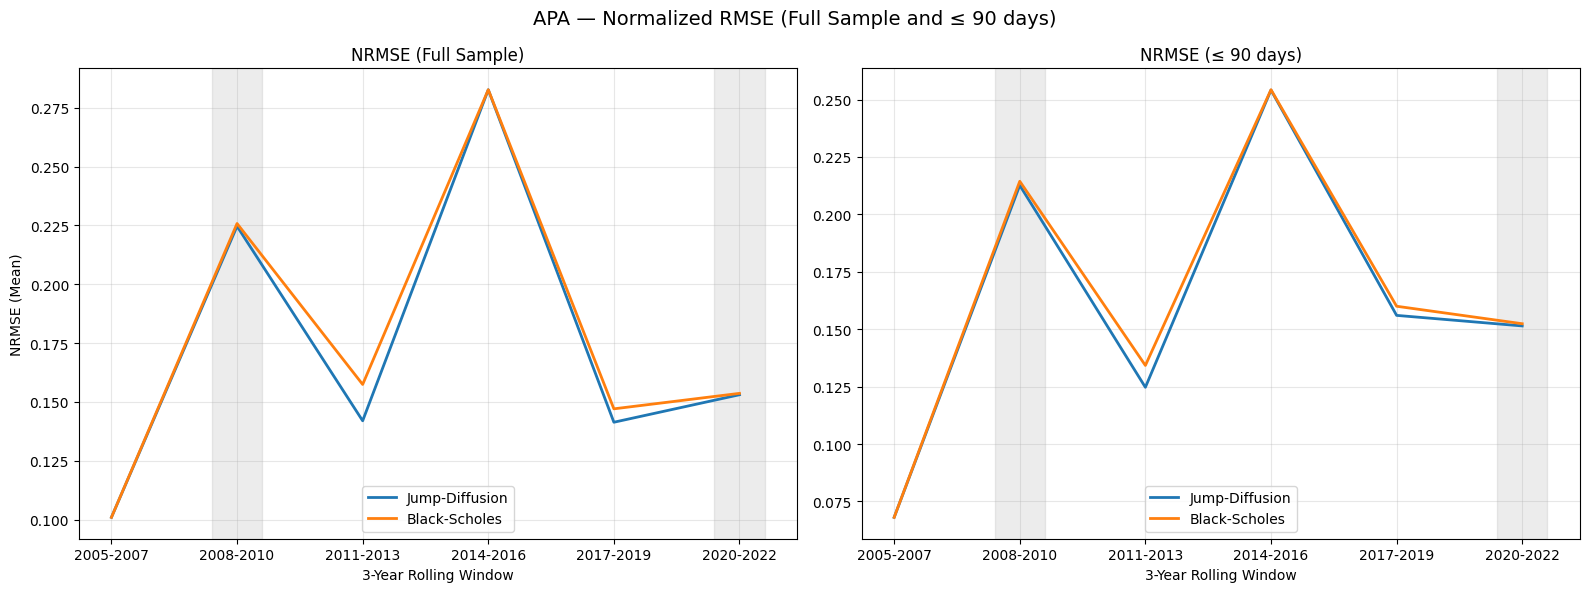

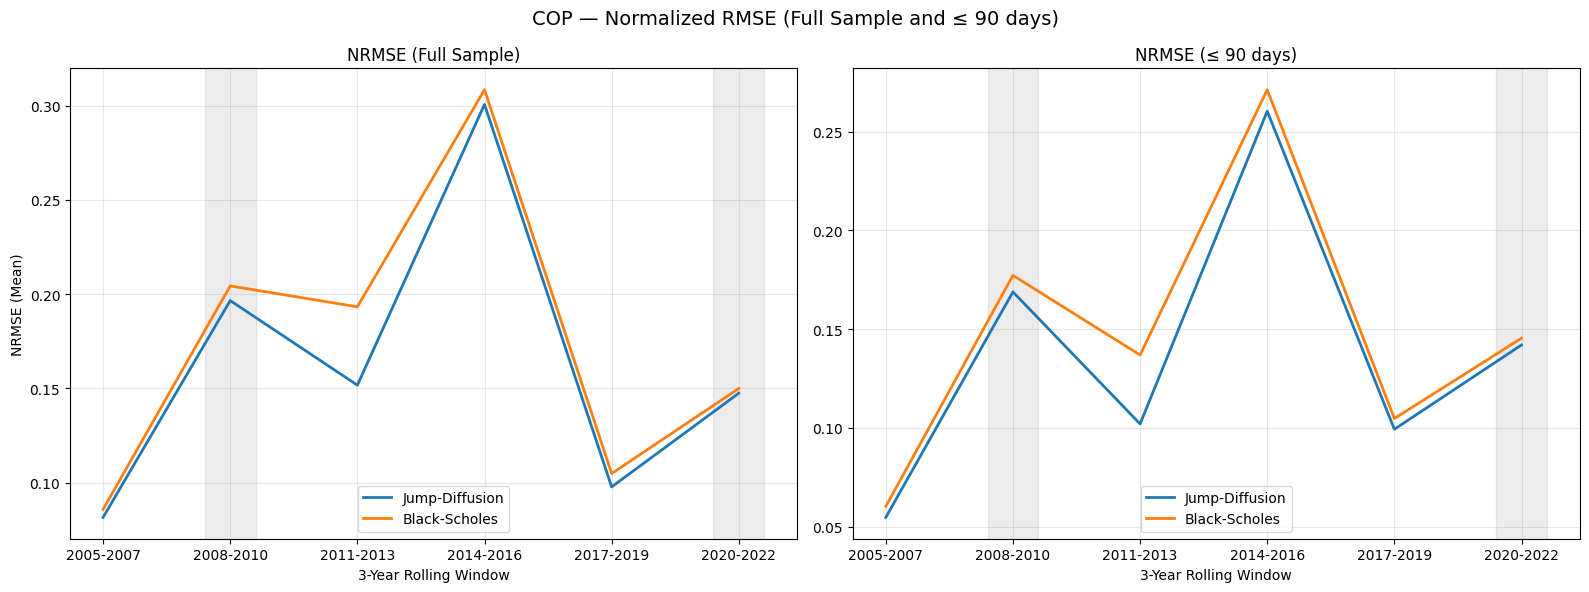

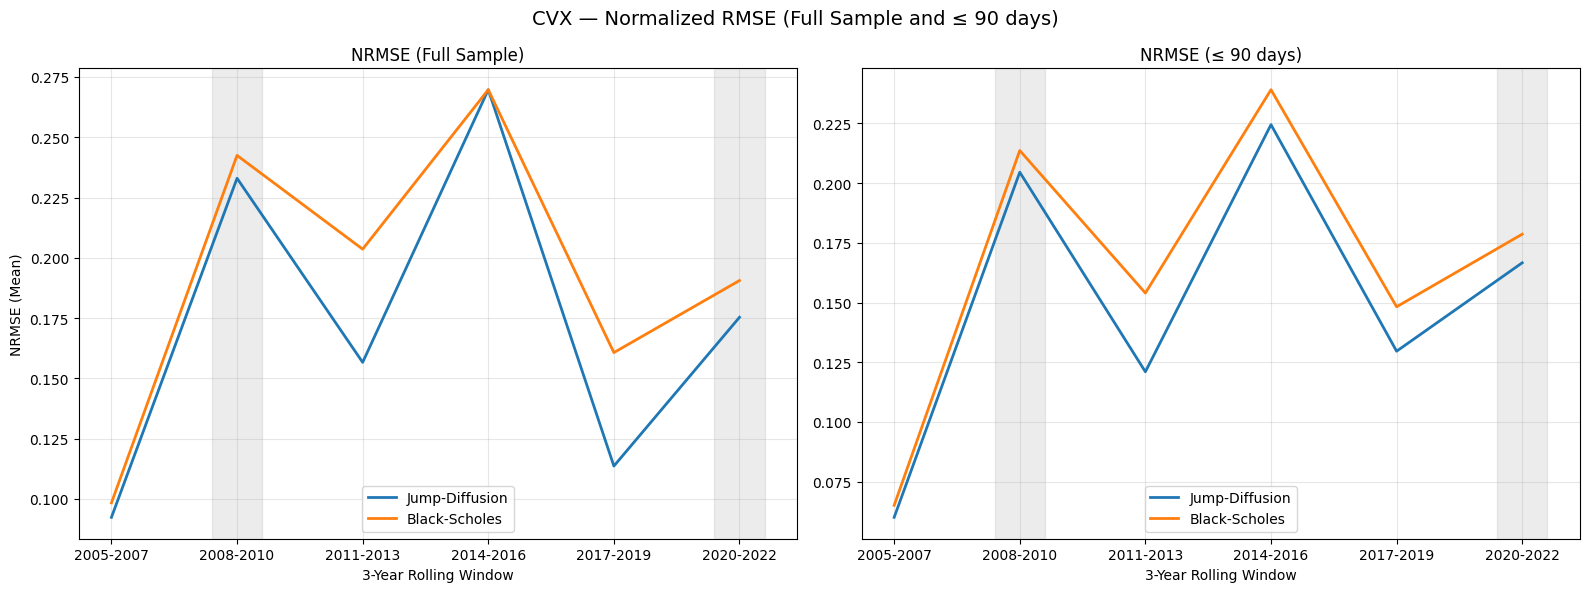

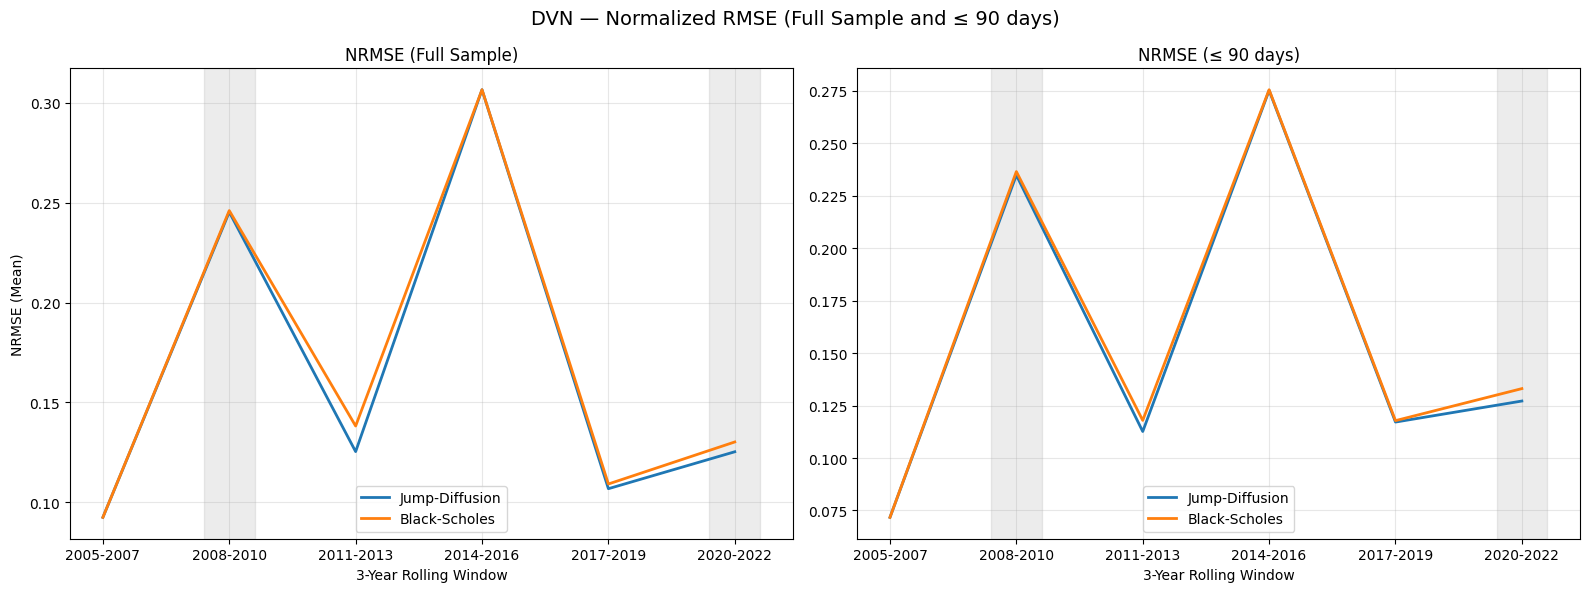

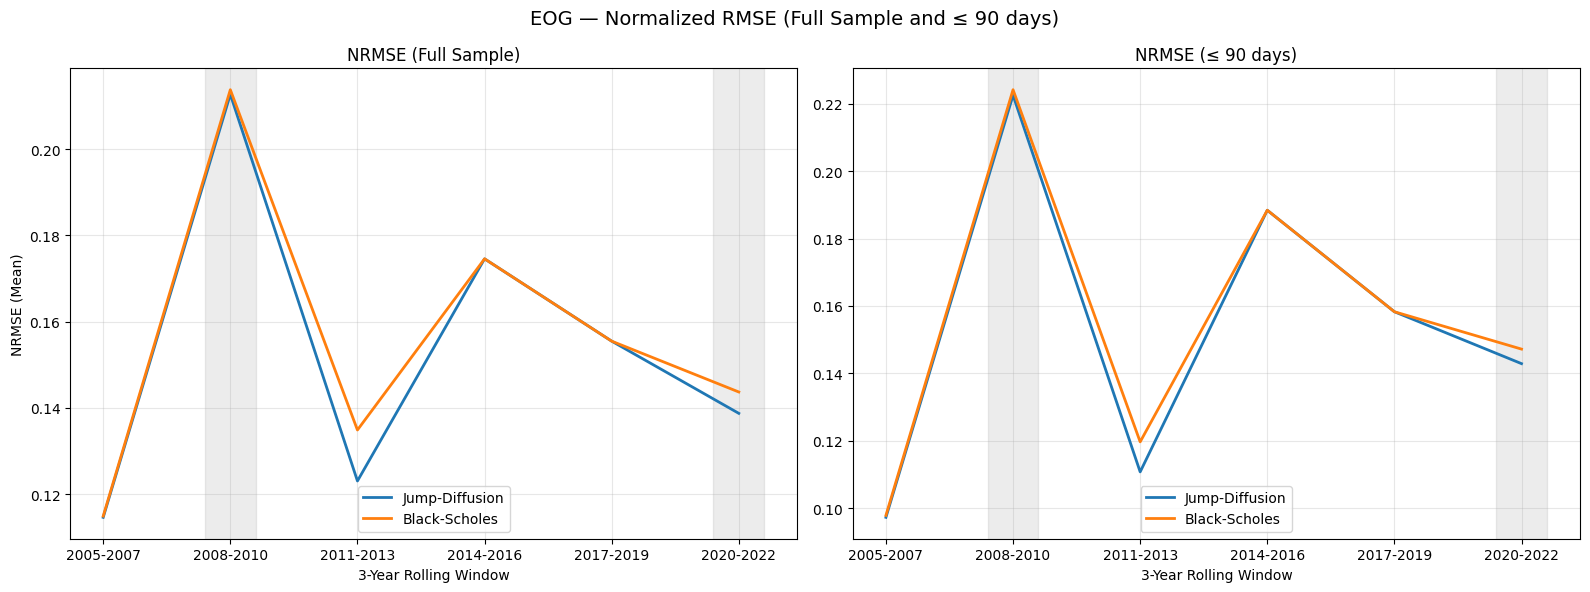

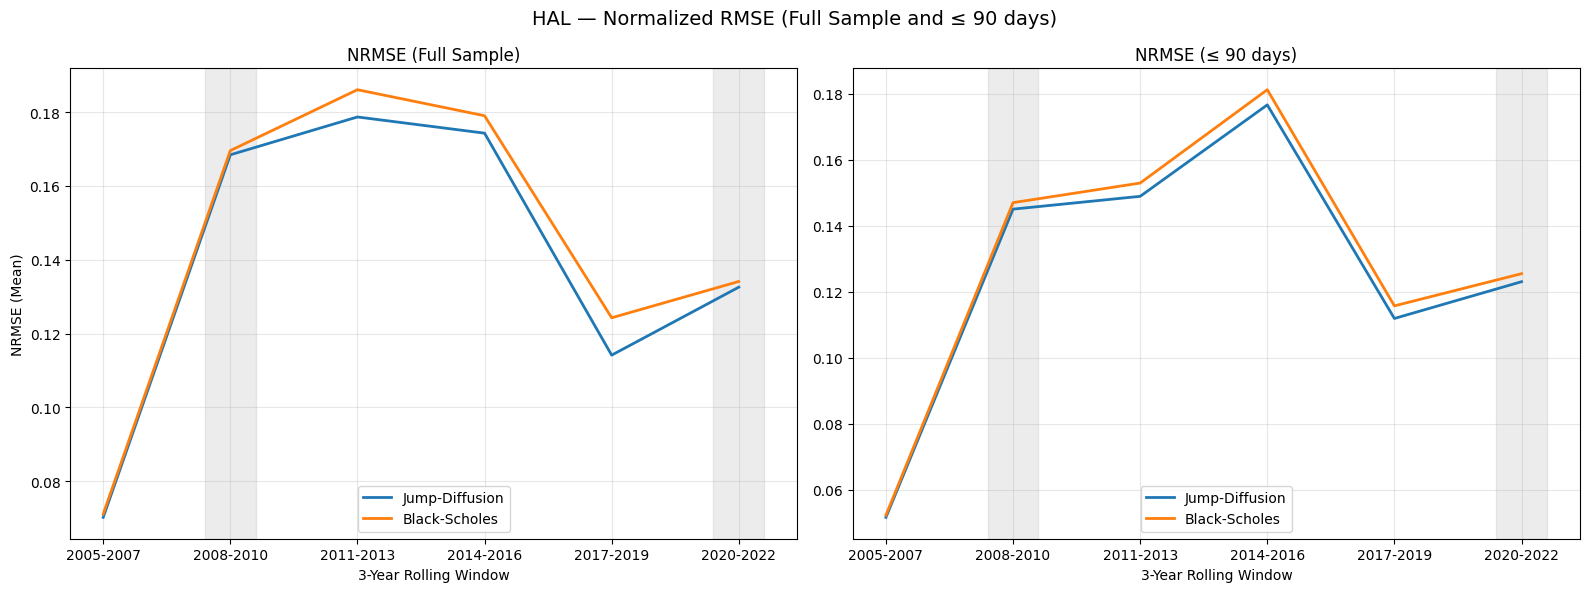

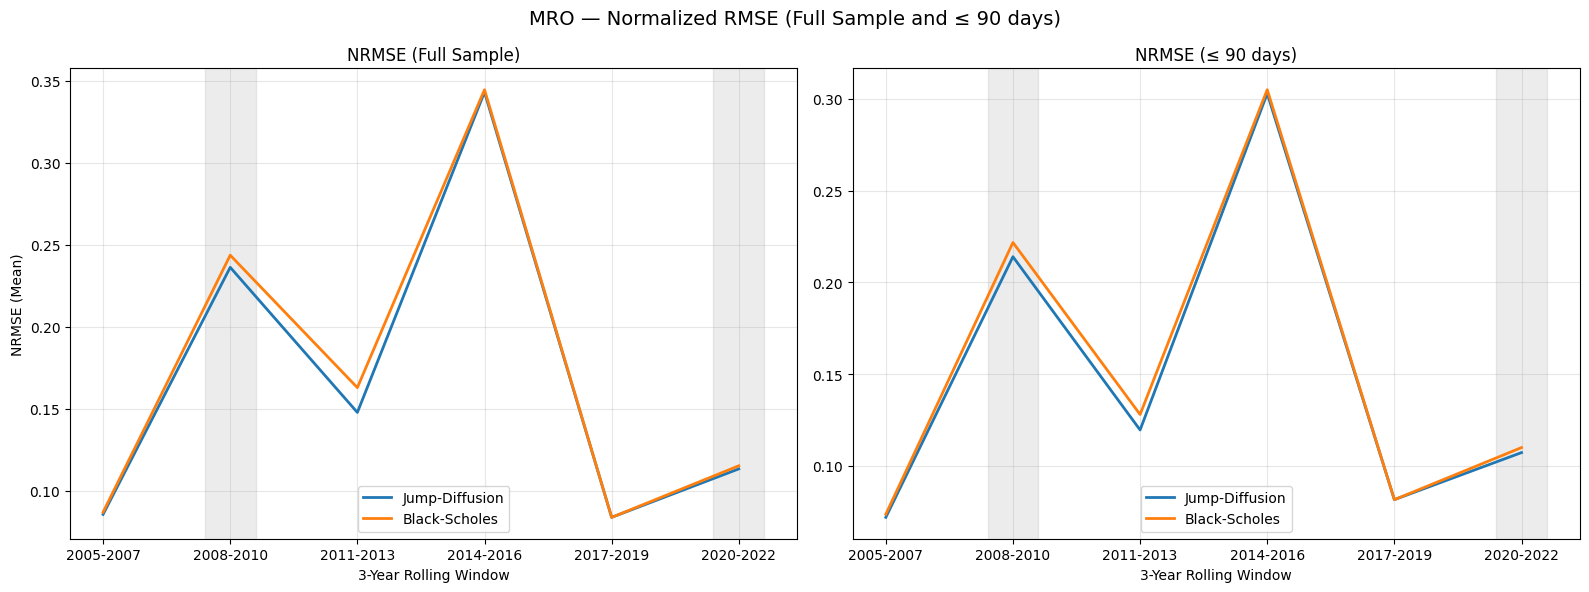

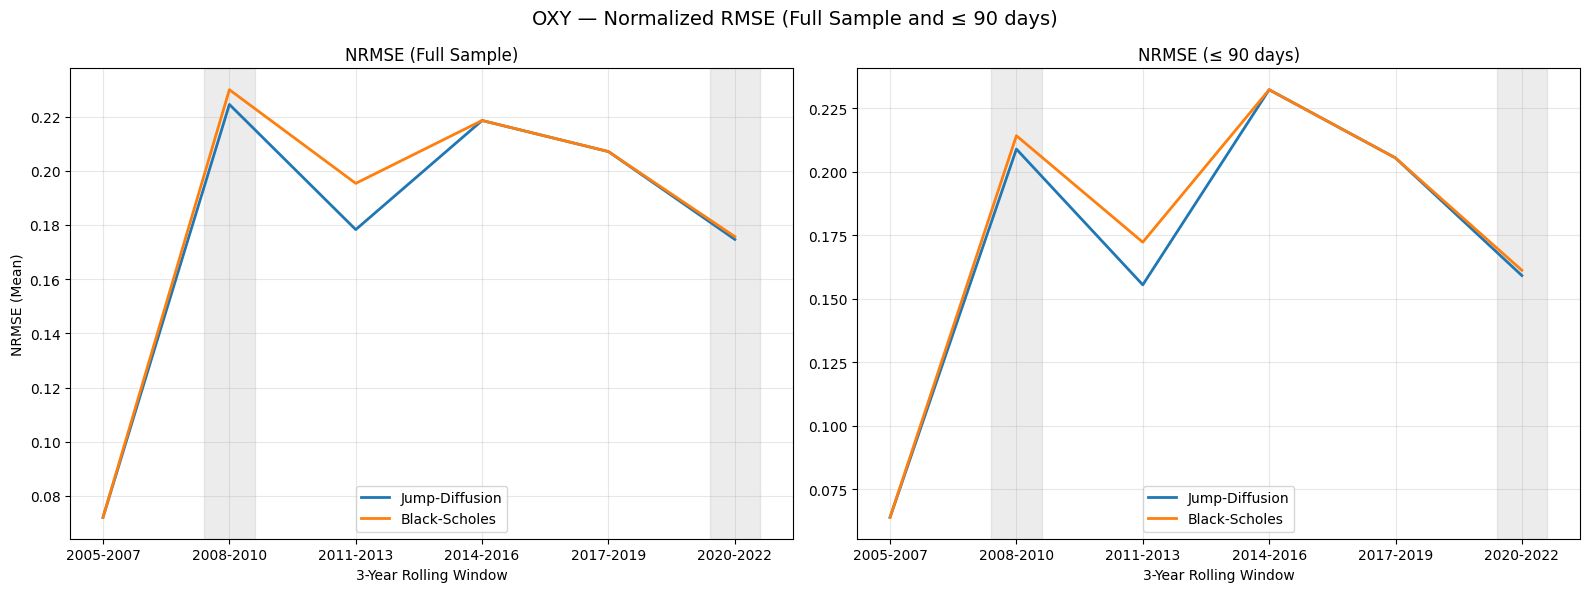

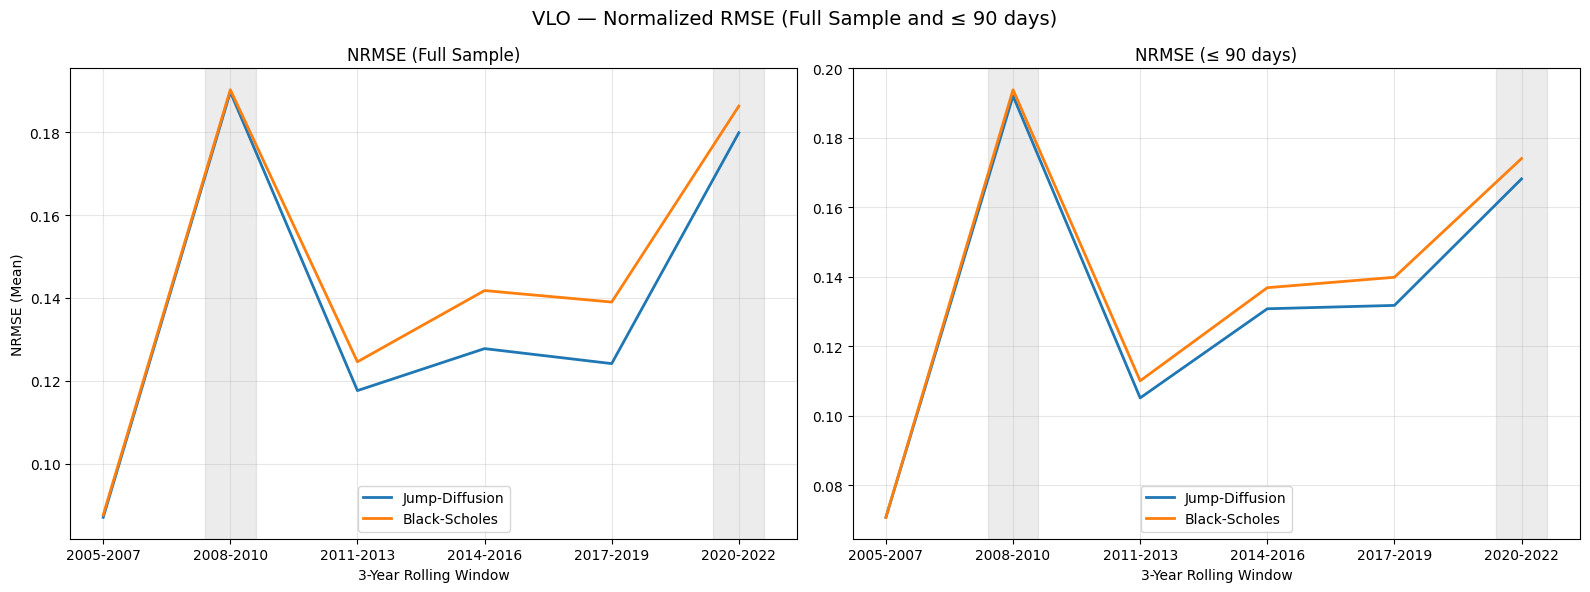

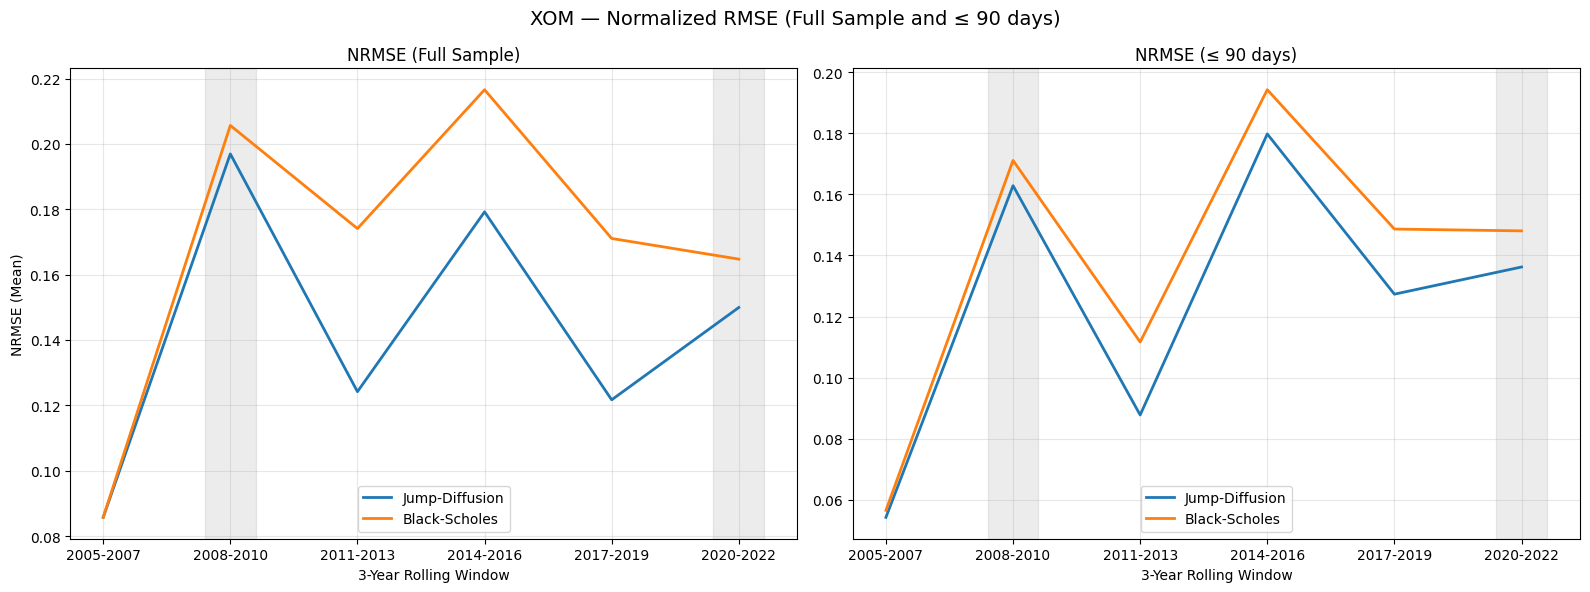

In [10]:
# Create higher-maturity estimation window column
stats_m_df["window"] = (
    stats_m_df["start_year"].astype(str) + "-" + stats_m_df["end_year"].astype(str)
)
stats_b_df["window"] = (
    stats_b_df["start_year"].astype(str) + "-" + stats_b_df["end_year"].astype(str)
)

# Create lower-maturity estimation window column
stats_m_df_mat["window"] = (
    stats_m_df_mat["start_year"].astype(str) + "-" + stats_m_df_mat["end_year"].astype(str)
)
stats_b_df_mat["window"] = (
    stats_b_df_mat["start_year"].astype(str) + "-" + stats_b_df_mat["end_year"].astype(str)
)

# Define crisis windows
crisis_windows = ["2008-2010", "2020-2022"]

# Run loop per ticker
for t in tickers_array:

    # Filter data
    # Unweighted estimation
    df_m = stats_m_df[stats_m_df["ticker"] == t].copy()
    df_b = stats_b_df[stats_b_df["ticker"] == t].copy()
    # Weighted estimation
    df_m_mat = stats_m_df_mat[stats_m_df_mat["ticker"] == t].copy()
    df_b_mat = stats_b_df_mat[stats_b_df_mat["ticker"] == t].copy()

    # Set rolling windows list to be used in the x-axis
    windows = df_m["window"].tolist()
    x = range(len(windows))

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)


    # Left panel: Full Sample
    ax1.plot(x, df_m["nrmse_mean"], label="Jump-Diffusion", linewidth=2)
    ax1.plot(x, df_b["nrmse_mean"], label="Black-Scholes", linewidth=2)

    ax1.set_title("NRMSE (Full Sample)")
    ax1.set_xlabel("3-Year Rolling Window")
    ax1.set_ylabel("NRMSE (Mean)")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(windows)
    ax1.grid(True, alpha=0.3)

    # Shade crisis periods
    for cw in crisis_windows:
        if cw in windows:
            i = windows.index(cw)
            ax1.axvspan(i - 0.2, i + 0.2, color="gray", alpha=0.15)

    ax1.legend()

    # Right panel: ≤ 90 days
    ax2.plot(x, df_m_mat["nrmse_mean"], label="Jump-Diffusion", linewidth=2)
    ax2.plot(x, df_b_mat["nrmse_mean"], label="Black-Scholes", linewidth=2)

    ax2.set_title("NRMSE (≤ 90 days)")
    ax2.set_xlabel("3-Year Rolling Window")
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(windows)
    ax2.grid(True, alpha=0.3)

    # Shade crisis periods
    for cw in crisis_windows:
        if cw in windows:
            i = windows.index(cw)
            ax2.axvspan(i - 0.2, i + 0.2, color="gray", alpha=0.15)

    ax2.legend()

    # Overall title
    fig.suptitle(f"{t} — Normalized RMSE (Full Sample and ≤ 90 days)", fontsize=14)

    plt.tight_layout()

    # Save
    if save_plt:
        os.makedirs("rmse_comp_mat", exist_ok=True)
        filepath = f"rmse_comp_mat/rmse_comp_mat_{t}.png"
        plt.savefig(filepath, dpi=300, bbox_inches="tight")

    plt.show()

## Plot Median % Error vs. Moneyness for Each Model (Full Sample vs. ≤ 90 days) (Fig. 16)

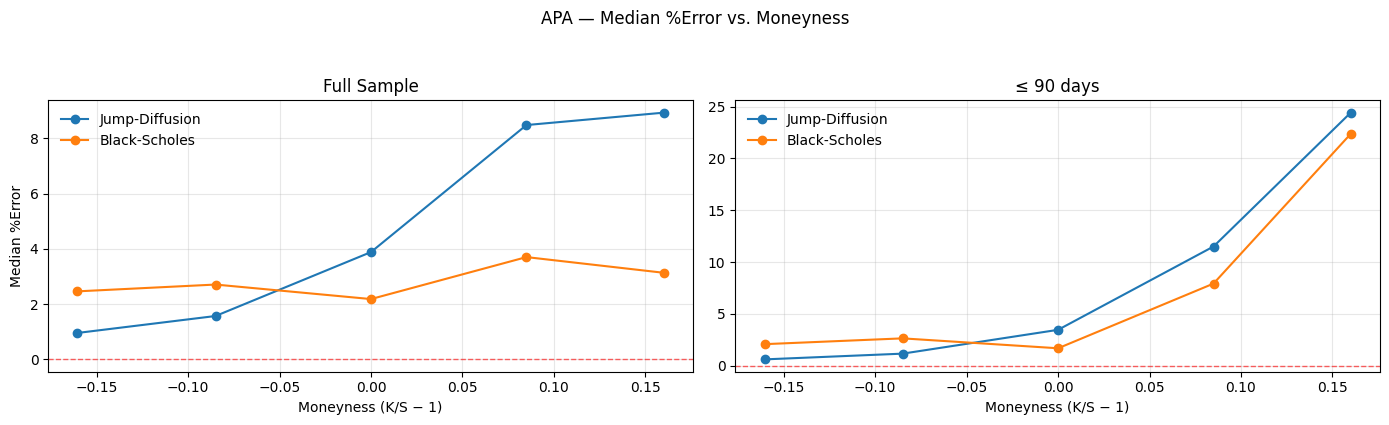

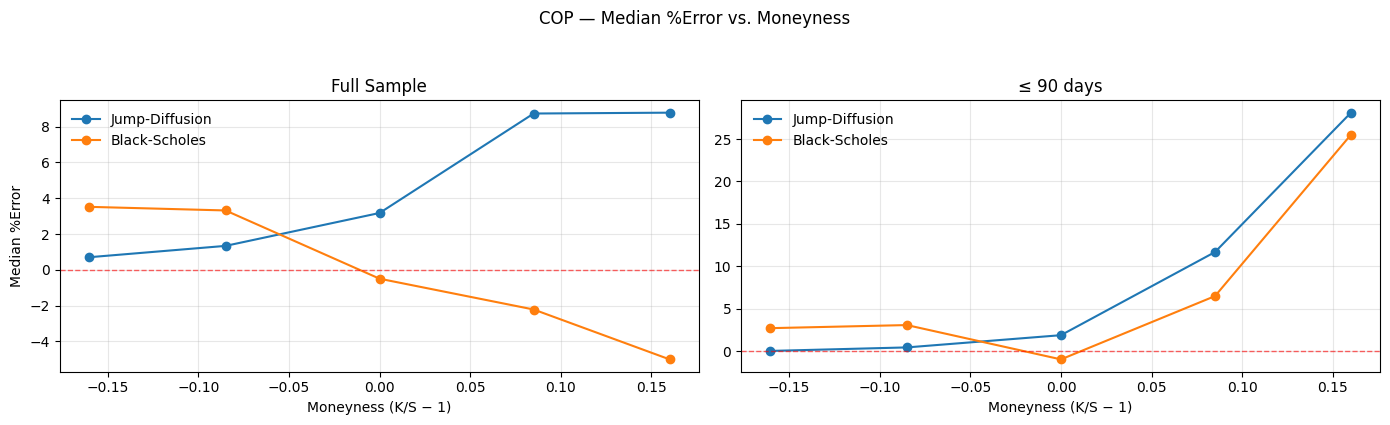

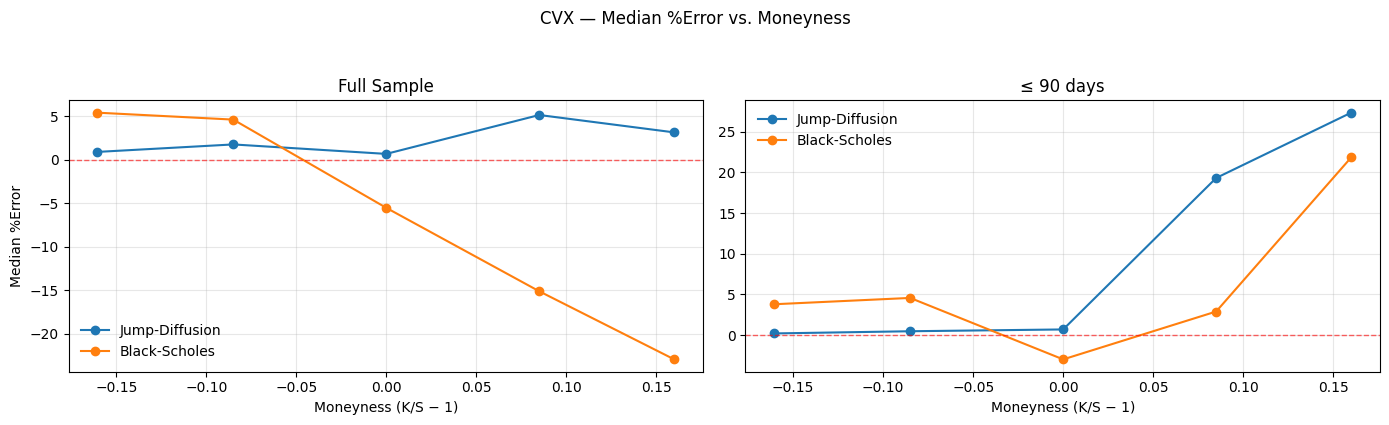

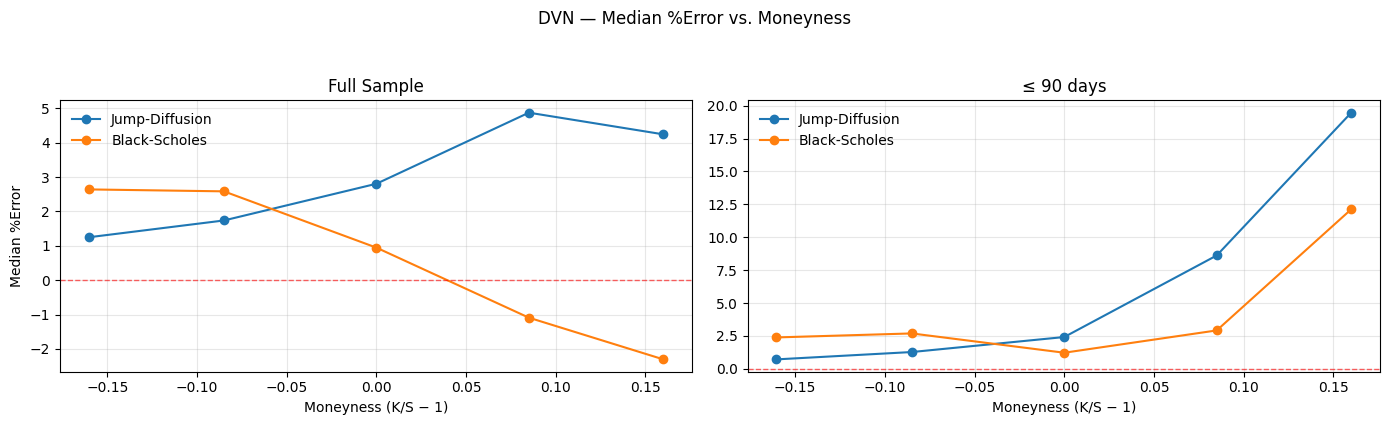

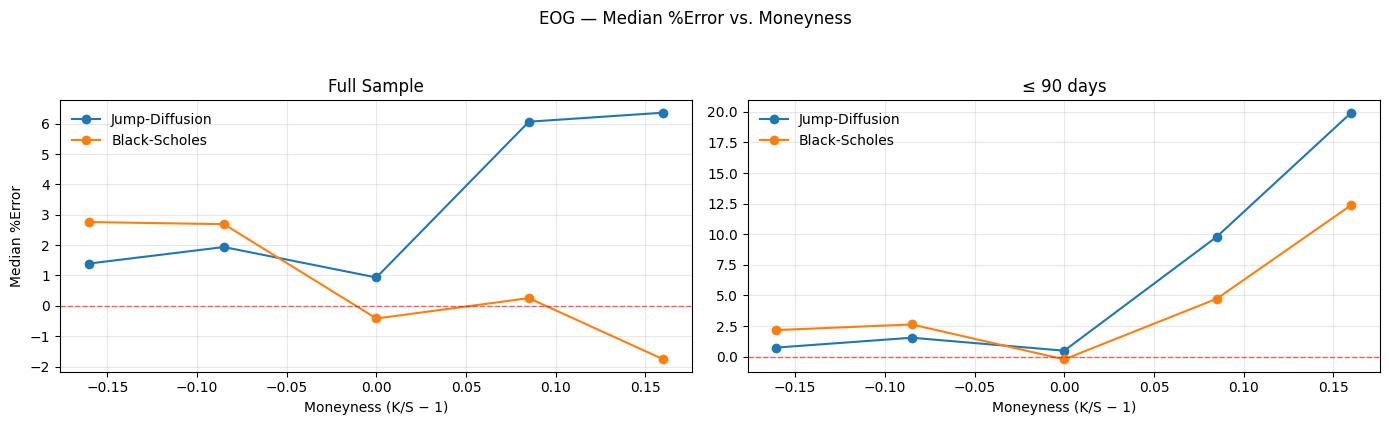

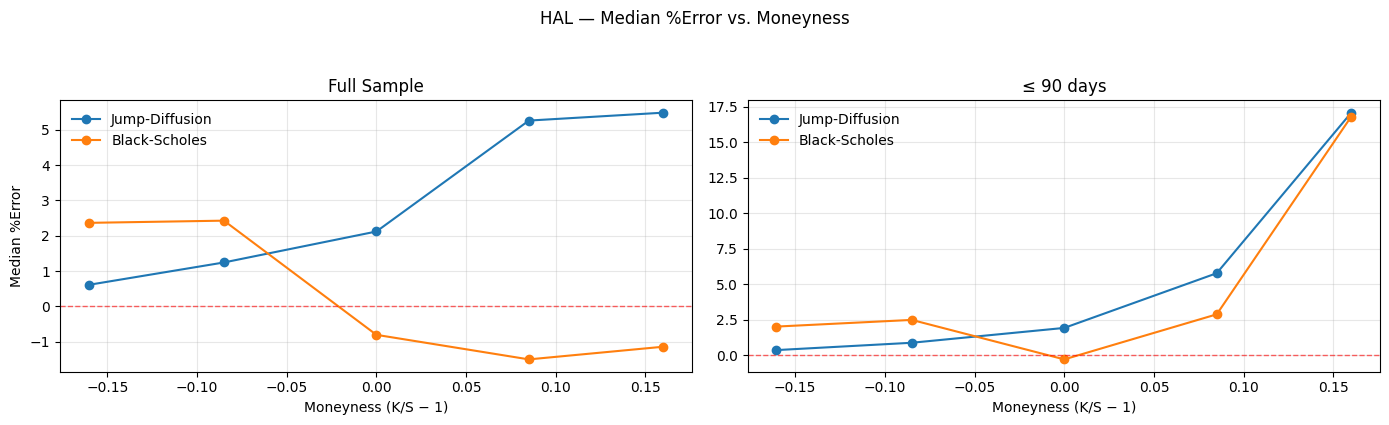

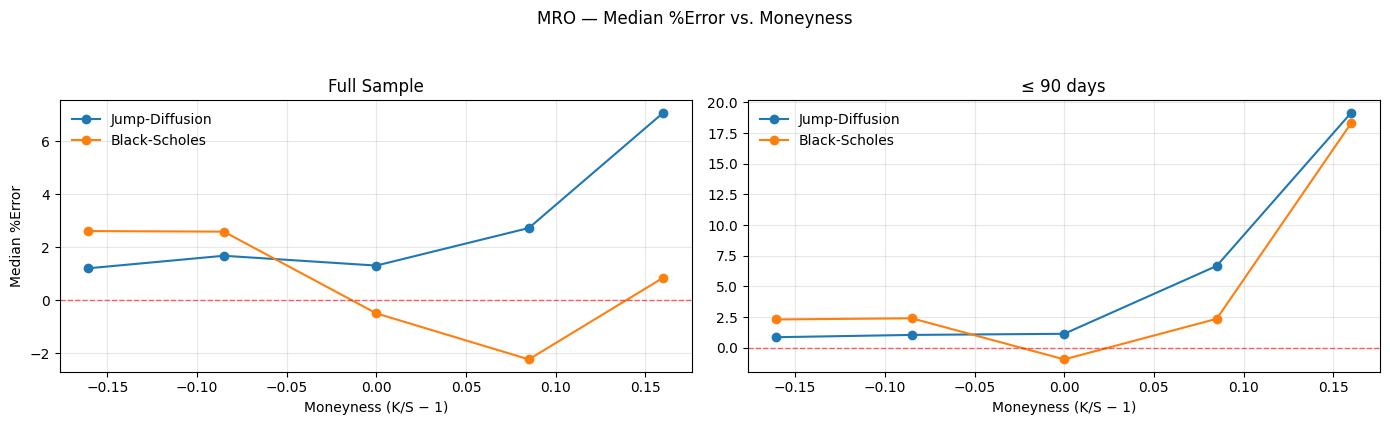

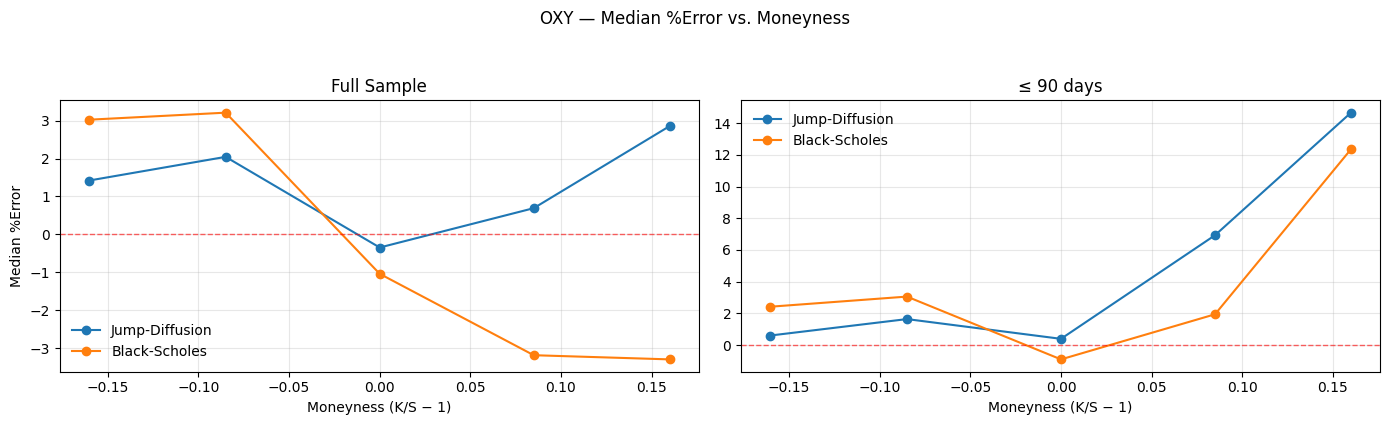

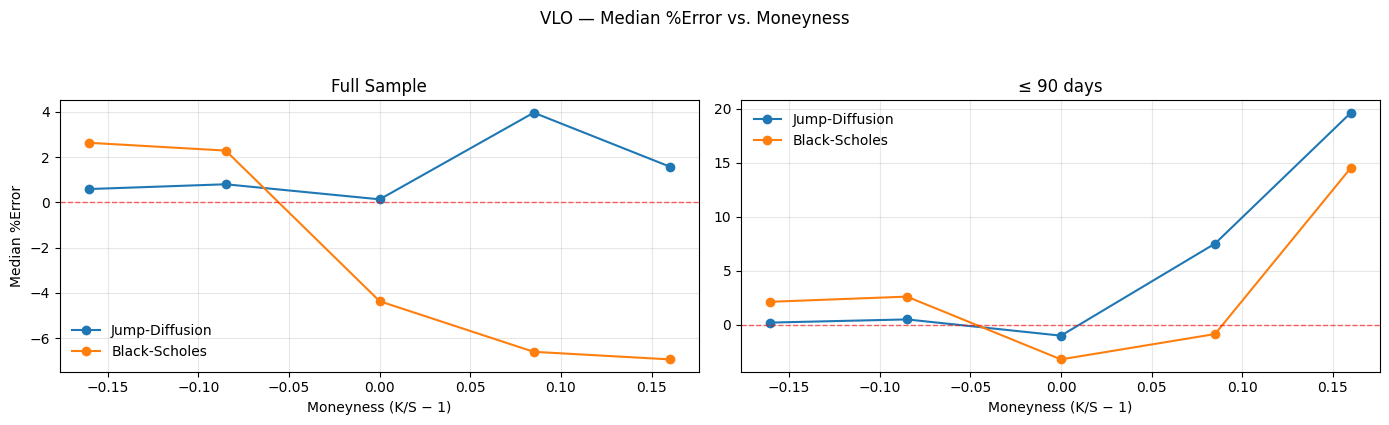

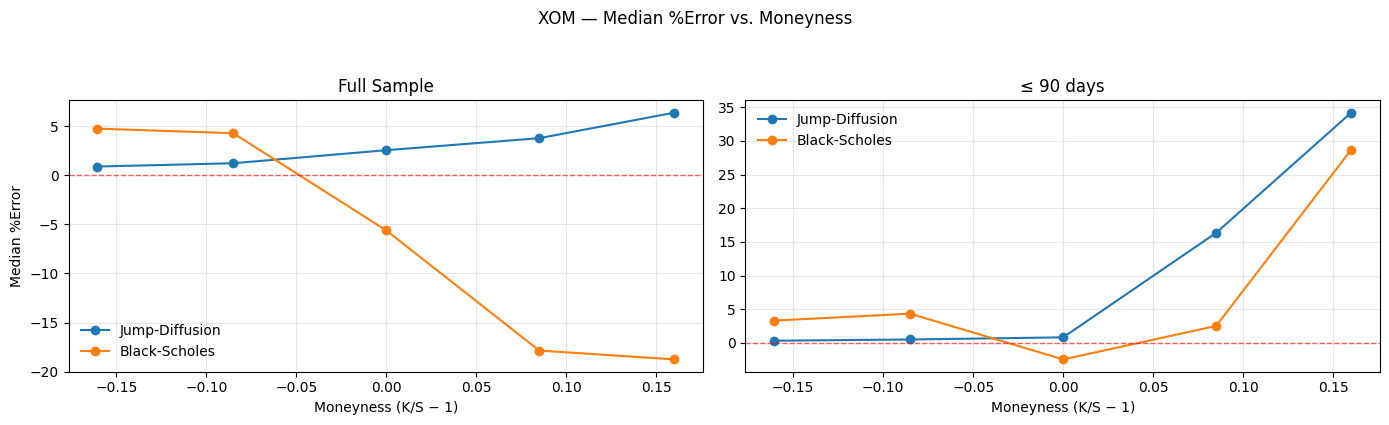

In [11]:
# Set both unweighted modeled prices dataframe together
models_money = [("Jump-Diffusion", price_m_df), ("Black-Scholes", price_b_df)]

# Set both weighted modeled prices dataframe together
models_mat = [("Jump-Diffusion", price_m_df_mat), ("Black-Scholes", price_b_df_mat)]

# Group the two cases
model_sets = [
    ("Full Sample", models_money),
    ("≤ 90 days", models_mat)
]

# Set moneyness bins
bins = [-0.20, -0.12, -0.05, 0.05, 0.12, 0.20]

for ticker in tickers_array:
    
    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    for ax, (title, models) in zip(axes, model_sets):
        
        for model_name, df_model in models:
            
            plot_df = df_model.loc[
                df_model["ticker"] == ticker,
                ["%moneyness", "%error"]
            ].dropna().copy()
            
            plot_df["moneyness_bin"] = pd.cut(
                plot_df["%moneyness"],
                bins=bins,
                include_lowest=True,
                right=True
            )

            smile = (
                plot_df.groupby("moneyness_bin", observed=True)["%error"]
                       .median()
                       .reset_index(name="med_error")
            )

            smile["moneyness_mid"] = smile["moneyness_bin"].apply(
                lambda iv: (iv.left + iv.right) / 2.0
            )

            smile = smile.dropna(subset=["med_error", "moneyness_mid"])

            ax.plot(
                smile["moneyness_mid"],
                smile["med_error"],
                marker="o",
                linewidth=1.5,
                label=model_name
            )

        # Horizontal zero line
        ax.axhline(0, linestyle="--", linewidth=1.0, alpha=0.6, color="red")

        # Titles and labels
        ax.set_title(f"{title}")
        ax.set_xlabel("Moneyness (K/S − 1)")
        ax.grid(True, alpha=0.3)
        ax.legend(frameon=False)

    # Shared Y label only once
    axes[0].set_ylabel("Median %Error")

    # Main title
    fig.suptitle(f"{ticker} — Median %Error vs. Moneyness", y=1.05)

    fig.tight_layout()

    if save_plt:
        os.makedirs("error_moneyness_comp_mat", exist_ok=True)
        filepath = f"error_moneyness_comp_mat/error_moneyness_comp_mat_{ticker}.png"
        fig.savefig(filepath, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()